**指针和引用**      
指针是一个变量，存储的是一个地址，指向内存的一个存储单元；

引用是原变量的一个别名，跟原来的变量实质上是同一个东西。    
int a = 996;     
int *p = &a; // p是指针, &在此是求地址运算      
int &r = a;          
指针和引用都可以作为函数参数，改变实参的值。




**指向常量的指针和常量指针**：     
**可以记成在const后的部分不能变**    
指向常量的指针const ina = 0; const int* p = &a;    
常量指量int a = 0; int* const p = &a;

**const**      
1.修饰变量，说明该变量不可以被修改     
2.修饰指针，分为指向常量的指针(pointer to const),和自身是常量的指针(常量指针,const pointer)    
3.修饰引用，指向常量的引用，用于形参，既避免了拷贝(只拷贝了地址)，又避免了函数对值的修改 bool isLongString_Good(const std::string& str)      
4.修饰成员函数，说明该成员函数内不能修改成员变量     
class Student {    
private:      
    std::string name;       
    int age;      
    mutable int access_count;  // mutable例外       
    
public:     
    // const成员函数   
    void display() const {     
        std::cout << name;           // ✅ 读取：OK    
        std::cout << age;            // ✅ 读取：OK      
        access_count++;              // ✅ mutable：OK     
        // name = "New";             // ❌ 修改：错误     
        // age = 20;                 // ❌ 修改：错误    
    }     
};

// 类
class A
{
private:
    const int a;                // 常对象成员，可以使用初始化列表或者类内初始化

public:
    // 构造函数
    A() : a(0) { };             //创建一个默认构造函数 把const成员a初始化为0 函数体为空
    A(int x) : a(x) { };        // 创建一个接受int参数的构造函数 把const成员a初始化为传入的参数值 函数体为空

    // const可用于对重载函数的区分
    int getValue();             // 普通成员函数
    int getValue() const;       // 常成员函数，不得修改类中的任何数据成员的值
};

void function()
{
    // 对象
    A b;                        // 普通对象，可以调用全部成员函数
    const A a;                  // 常对象，只能调用常成员函数
    const A *p = &a;            // 指针变量，指向常对象
    const A &q = a;             // 指向常对象的引用

    // 指针
    char greeting[] = "Hello";
    char* p1 = greeting;                // 指针变量，指向字符数组变量
    const char* p2 = greeting;          // 指针变量，指向字符数组常量（const 后面是 char，说明指向的字符（char）不可改变）
    char* const p3 = greeting;          // 自身是常量的指针，指向字符数组变量（const 后面是 p3，说明 p3 指针自身不可改变）
    const char* const p4 = greeting;    // 自身是常量的指针，指向字符数组常量
}

// 函数
void function1(const int Var);           // 传递过来的参数在函数内不可变
void function2(const char* Var);         // 参数指针所指内容为常量
void function3(char* const Var);         // 参数指针为常量
void function4(const int& Var);          // 引用参数在函数内为常量

// 函数返回值
const int function5();      // 返回一个常数
const int* function6();     // 返回一个指向常量的指针变量，使用：const int *p = function6();
int* const function7();     // 返回一个指向变量的常指针，使用：int* const p = function7();

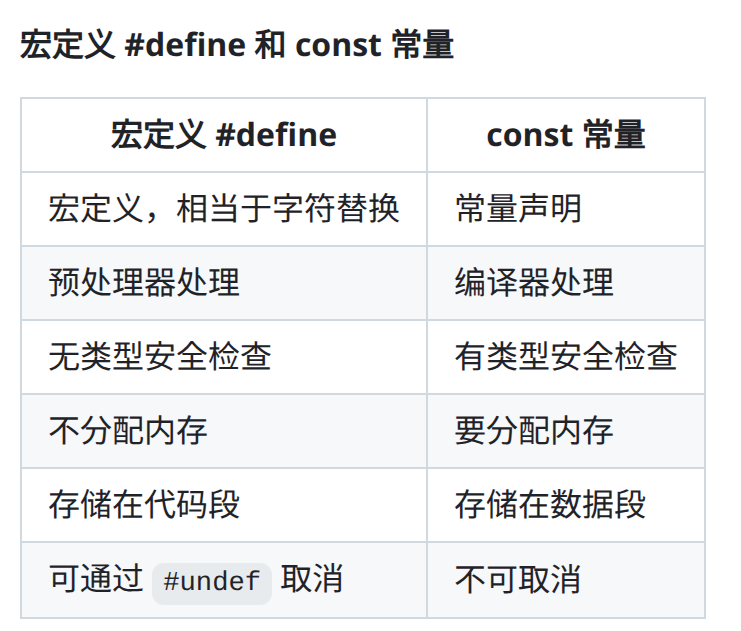      
宏定义不分配内存，只是告诉预处理器看到这个标识符就替换，真正的内存分配发生在使用这些值的地方       
赋值给变量：在变量的内存位置     
作为数组大小：影响数组的内存分配     
作为函数参数：可能在寄存器或者在栈上         
嵌入到cpu指令中

**static**     
1.修饰普通变量，修饰遍历那个的存储区域和生命周期，使变量存储在静态区，在main函数运行前就分配了空间，如果有初始值就用初始值进行初始化，如果没有就用系统默认值进行初始化；函数内部的用static修饰的变量，不会随着函数销毁而消失，但是函数外部不能直接访问，可以返回static变量的指针或者引用来访问    
2.修饰普通函数，表明函数的作用范围，仅在定义该函数的文家内才能使用    
3.修饰成员变量，修饰成员变量使所有的对象只保存一个该变量，而且不需要生成对象就可以访问该成员    
4.修饰成员函数，修饰成员函数使得不需要生成对象就可以访问该函数，但是在static函数内不能访问非静态成员